In [ ]:
import os
import time
import matplotlib.pyplot as plt
import numpy as np
import torch
import warnings
import cv2
from PIL import Image
from sklearn.metrics import accuracy_score
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from google.colab import drive
from torchvision.transforms import ToTensor, PILToTensor

warnings.filterwarnings('ignore')
drive.mount('/content/drive')
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
cuda:0


In [ ]:
RGB_DIR = 'drive/MyDrive/dataset/segmentation-1/CameraRGB/'
MASK_DIR = 'drive/MyDrive/dataset/segmentation-1/CameraSeg/'

In [ ]:
image = Image.open(RGB_DIR + '02_00_000.png').convert('RGB')
mask = Image.open(MASK_DIR + '02_00_000.png').convert('L')

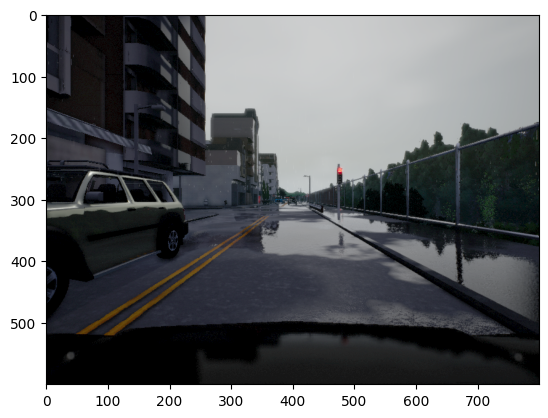

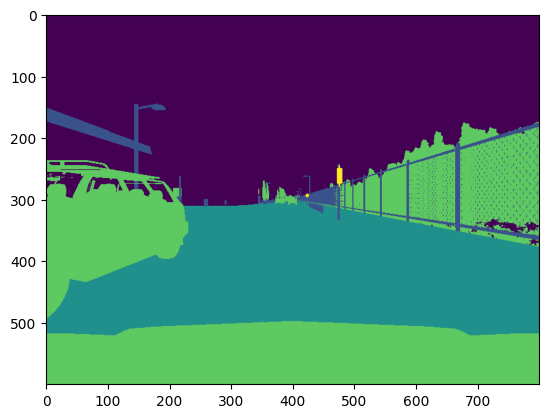

In [ ]:
plt.imshow(image)
plt.show()
plt.imshow(mask)
plt.show()

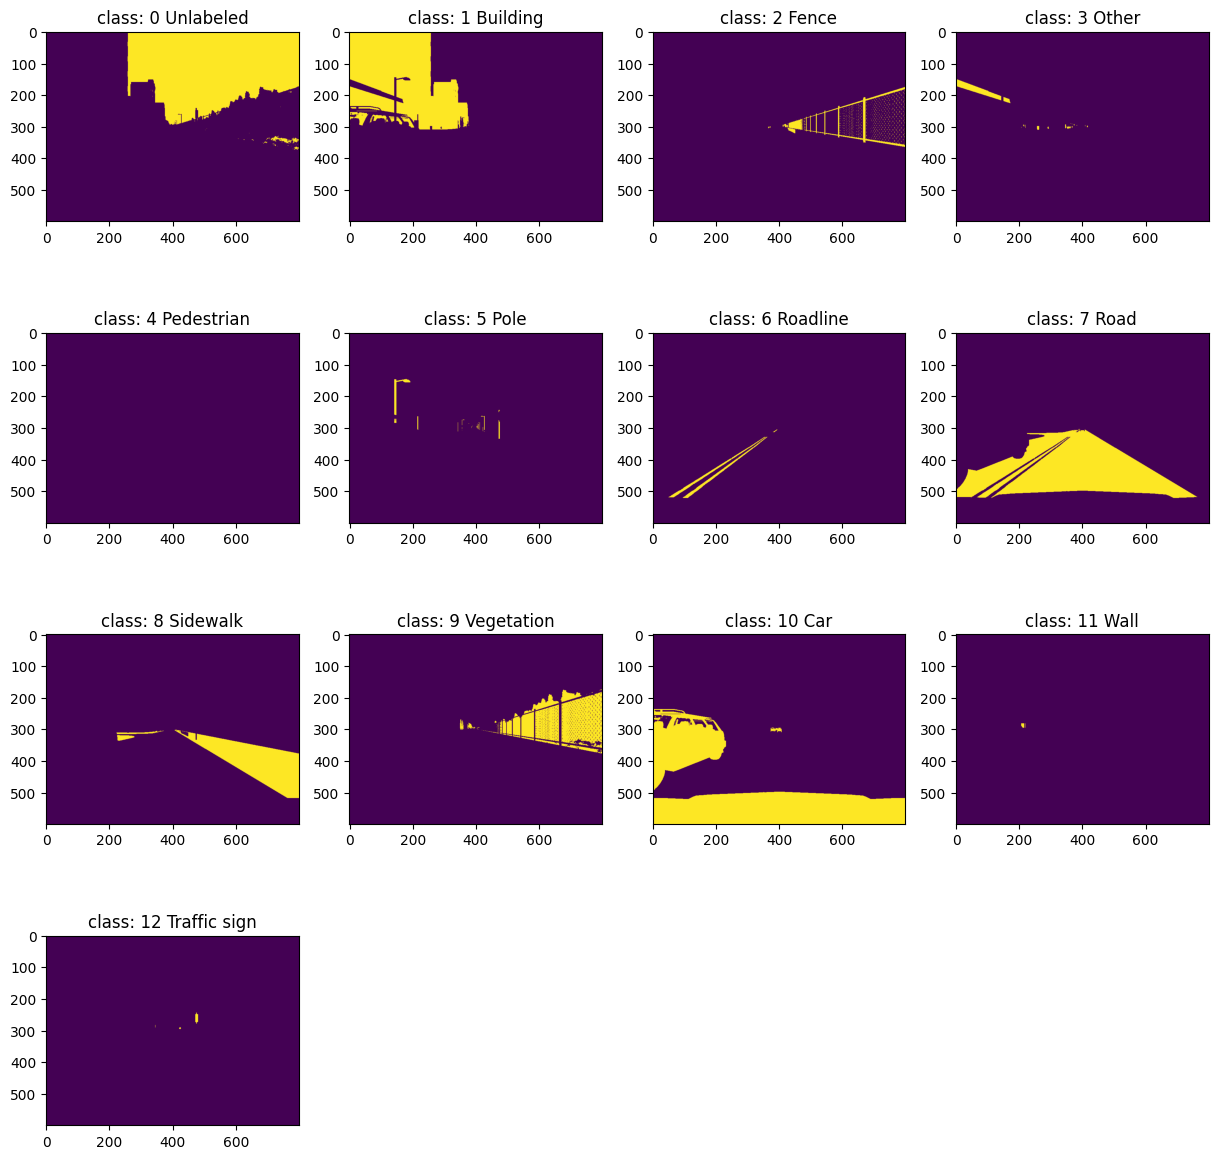

In [ ]:
labels = ['Unlabeled','Building','Fence','Other',
          'Pedestrian', 'Pole', 'Roadline', 'Road',
          'Sidewalk', 'Vegetation', 'Car','Wall',
          'Traffic sign']
plt.figure(figsize=(15, 15))

for i in range(13):
    mask = plt.imread(MASK_DIR + '02_00_000.png') * 255
    mask = np.where(mask == i, 255, 0)
    mask = mask[:,:,0]

    plt.subplot(4, 4, i+1)
    plt.title(f'class: {i} {labels[i]}')
    plt.imshow(mask)
plt.show()

In [ ]:
class SelfDrivingCarsDataset(Dataset):
    def __init__(self, transform_img=None, transform_mask=None):
        self.transform_img = transform_img
        self.transform_mask = transform_mask

        self.list_files()

    def list_files(self):
        self.images = sorted([RGB_DIR + i for i in os.listdir(RGB_DIR)])
        self.masks = sorted([MASK_DIR + i for i in os.listdir(MASK_DIR)])

    def __getitem__(self, idx):
        image = Image.open(self.images[idx]).convert('RGB')
        mask = Image.open(self.masks[idx]).convert('L')

        if self.transform_img:
            image = self.transform_img(image)
        if self.transform_mask:
            mask = self.transform_mask(mask)

        sample = {'image': image, 'mask': mask}

        return sample

    def __len__(self):
        return len(self.images)

In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
accs, losses = [], []

def train_model(model, criterion, dataloader, optimizer, num_epochs):
    model.to(device)

    for epoch in range(1, num_epochs + 1):
        print('-' * 10)
        print('Epoch {}/{}'.format(epoch, num_epochs))

        mean_acc = 0
        mean_loss = 0

        for sample in dataloader:
            inputs = sample['image'].to(device)

            masks = sample['mask'].type(torch.LongTensor)
            masks = torch.squeeze(masks, 1)
            masks = masks.to(device)
            optimizer.zero_grad()

            outputs = model(inputs)

            loss = criterion(outputs, masks)
            mean_loss += loss

            pred_y = torch.argmax(outputs, 1)

            acc = (pred_y == masks).sum().float() /  torch.numel(masks)
            mean_acc += acc

            loss.backward()
            optimizer.step()
        mean_acc /= len(dataloader)
        mean_loss /= len(dataloader)

        accs.append(mean_acc)
        losses.append(mean_loss)

        print(mean_acc, mean_loss)
    return model

In [ ]:
BATCH_SIZE = 8
MAX_EPOCH = 300

transfrom_image = transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor(),
                                      transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])
transfrom_mask = transforms.Compose([transforms.Resize((224, 224)), PILToTensor()])

ds = SelfDrivingCarsDataset(transfrom_image, transfrom_mask)
dl = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

In [ ]:
class UNet(nn.Module):
  def __init__(self):
    super(UNet, self).__init__()
    self.left_conv1 = nn.Sequential(
      nn.Conv2d(3, 32, (3, 3), padding=1),
      nn.ReLU(),
      nn.Conv2d(32, 32, (3, 3), padding=1),
      nn.ReLU(),
    )

    self.left_conv2 = nn.Sequential(
      nn.Conv2d(32, 64, (3, 3), padding=1),
      nn.ReLU(),
      nn.Conv2d(64, 64, (3, 3), padding=1),
      nn.ReLU(),
    )

    self.left_conv3 = nn.Sequential(
      nn.Conv2d(64, 128, (3, 3), padding=1),
      nn.ReLU(),
      nn.Conv2d(128, 128, (3, 3), padding=1),
      nn.ReLU(),
    )

    self.left_conv4 = nn.Sequential(
      nn.Conv2d(128, 256, (3, 3), padding=1),
      nn.ReLU(),
      nn.Conv2d(256, 256, (3, 3), padding=1),
      nn.ReLU(),
    )

    self.right_conv1 = nn.Sequential(
      nn.Conv2d(512, 256, (3, 3), padding=1),
      nn.ReLU(),
      nn.Conv2d(256, 128, (3, 3), padding=1),
      nn.ReLU(),
    )
    self.right_conv2 = nn.Sequential(
      nn.Conv2d(256, 128, (3, 3), padding=1),
      nn.ReLU(),
      nn.Conv2d(128, 64, (3, 3), padding=1),
      nn.ReLU()
    )

    self.right_conv3 = nn.Sequential(
      nn.Conv2d(128, 64, (3, 3), padding=1),
      nn.ReLU(),
      nn.Conv2d(64, 32, (3, 3), padding=1),
      nn.ReLU()
    )

    self.right_conv4 = nn.Sequential(
      nn.Conv2d(64, 32, (3, 3), padding=1),
      nn.ReLU(),
      nn.Conv2d(32, 13, 1),
    )

    self.up = nn.UpsamplingBilinear2d(scale_factor=2)
    self.pool = nn.MaxPool2d(kernel_size=2)
    self.softmax = nn.LogSoftmax(dim=1)


  def forward(self, x):
    left1 = self.left_conv1(x)
    pool1 = self.pool(left1)
    left2 = self.left_conv2(pool1)
    pool2 = self.pool(left2)
    left3 = self.left_conv3(pool2)
    pool3 = self.pool(left3)
    left4 = self.left_conv4(pool3)
    pool4 = self.pool(left4)

    up1 = self.up(pool4)
    concat1 = torch.cat((up1, left4), 1)
    right1 = self.right_conv1(concat1)

    up2 = self.up(right1)
    concat2 = torch.cat((up2, left3), 1)
    right2 = self.right_conv2(concat2)

    up3 = self.up(right2)
    concat3 = torch.cat((up3, left2), 1)
    right3 = self.right_conv3(concat3)

    up4 = self.up(right3)
    concat4 = torch.cat((up4, left1), 1)
    output = self.softmax(self.right_conv4(concat4))

    return output

In [ ]:
unet = UNet()

weights = torch.tensor([0.02]+([0.245]*12)).to(device)

criterion = torch.nn.NLLLoss(weight=weights)
optimizer = torch.optim.Adam(unet.parameters(), lr=1e-4)
train_model(unet, criterion, dl, optimizer, MAX_EPOCH)

----------
Epoch 1/300
tensor(0.3914, device='cuda:0') tensor(1.1706, device='cuda:0', grad_fn=<DivBackward0>)
----------
Epoch 2/300
tensor(0.5558, device='cuda:0') tensor(0.5565, device='cuda:0', grad_fn=<DivBackward0>)
----------
Epoch 3/300
tensor(0.7134, device='cuda:0') tensor(0.4595, device='cuda:0', grad_fn=<DivBackward0>)
----------
Epoch 4/300
tensor(0.7689, device='cuda:0') tensor(0.4198, device='cuda:0', grad_fn=<DivBackward0>)
----------
Epoch 5/300
tensor(0.7767, device='cuda:0') tensor(0.4132, device='cuda:0', grad_fn=<DivBackward0>)
----------
Epoch 6/300
tensor(0.8051, device='cuda:0') tensor(0.3720, device='cuda:0', grad_fn=<DivBackward0>)
----------
Epoch 7/300
tensor(0.8100, device='cuda:0') tensor(0.3684, device='cuda:0', grad_fn=<DivBackward0>)
----------
Epoch 8/300
tensor(0.8150, device='cuda:0') tensor(0.3486, device='cuda:0', grad_fn=<DivBackward0>)
----------
Epoch 9/300
tensor(0.8152, device='cuda:0') tensor(0.3461, device='cuda:0', grad_fn=<DivBackward0>)
-

KeyboardInterrupt: 

In [ ]:
torch.save(unet, "unet1.pt")

In [ ]:
def convert(tensor):
    return [t.detach().cpu().numpy() for t in tensor]

def plot_build(title, data):
    plt.figure(figsize=(12, 8))
    plt.plot(range(len(data)), data)
    plt.xlabel("Epoch")
    plt.ylabel(title)
    plt.show()

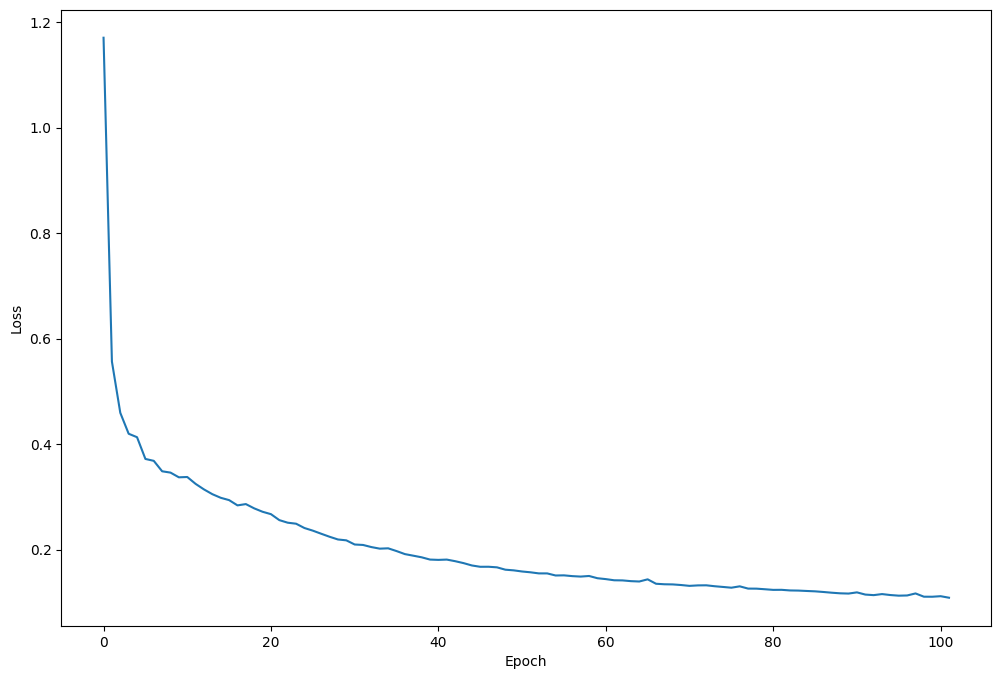

In [ ]:
plot_build('Loss', convert(losses))

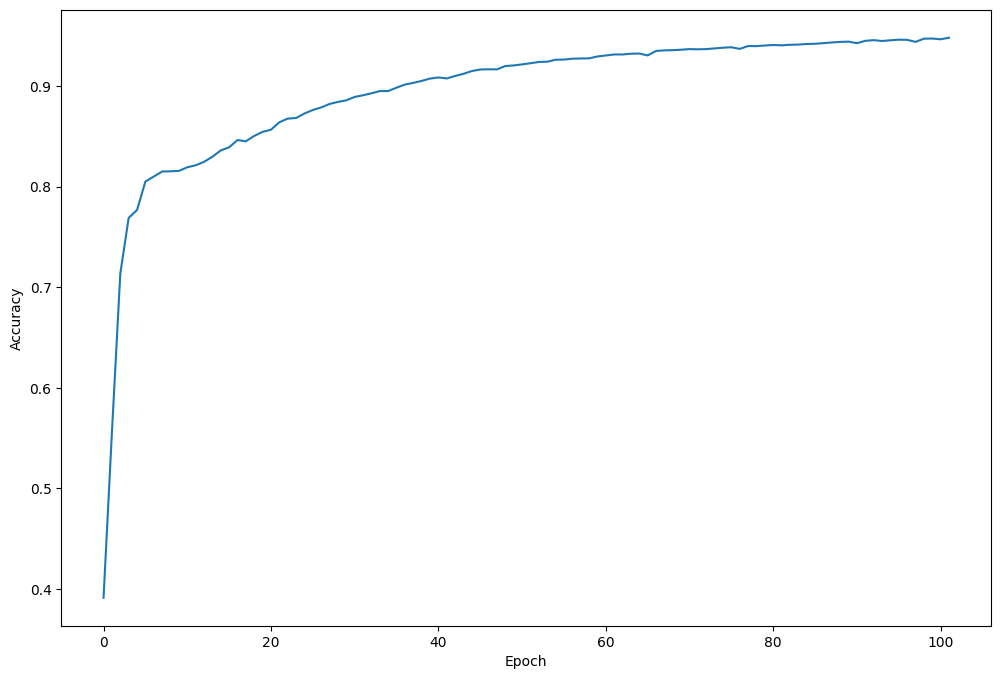

In [ ]:
plot_build('Accuracy', convert(accs))

In [ ]:
def show_result(model, dl):
    item = next(iter(dl))
    model.eval()
    model.to(device)

    image = item['image']
    image = image.to(device)
    pred = model(image)

    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 15))
    axes[0].imshow(item['image'][0].permute(1, 2, 0).numpy())
    axes[1].imshow(item['mask'][0].permute(1, 2, 0).numpy())
    axes[2].imshow(torch.argmax(pred[0], dim=0).unsqueeze(2).cpu())
    plt.show()

In [ ]:
unet = torch.load("unet1.pt", weights_only=False)

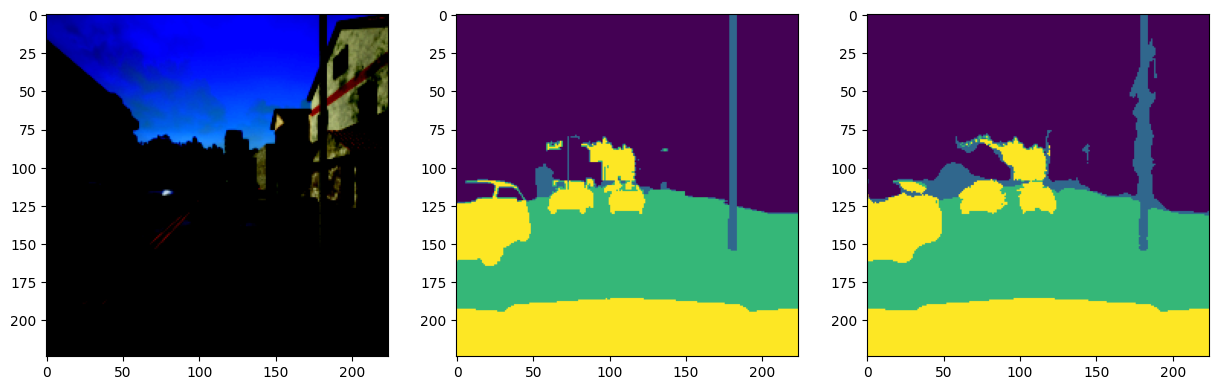

In [ ]:
show_result(unet, dl)